# 1. 데이터 분석 준비

## 0. 환경설정

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path

# 폰트 테마 설정
sns.set_theme(style="whitegrid")
# 한글 폰트 설정 (맑은 고딕) — set_theme 이후에 지정해야 덮어쓰이지 않음
plt.rc("font", family="Malgun Gothic")
# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

## 1. 데이터 불러오기

In [3]:
integration = pd.read_csv("../CSV_files/통합쿼리.csv")

integration.head()

,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,label_churn_28d,date_registration,date_unregistration,module_presentation_length,n_assessment_submitted_28,avg_score_28,avg_submit_delay_28,total_click_28,active_days_28,distinct_resources_28
0,6516,AAA,2014J,M,Scotland,HE Qualification,80-90%,55<=,0,60,...,False,-52.0,NaN,269,1,60.0,-2.0,570,19,25
1,8462,DDD,2013J,M,London Region,HE Qualification,30-40%,55<=,0,90,...,False,-137.0,119.0,261,0,NaN,NaN,294,15,73
2,8462,DDD,2014J,M,London Region,HE Qualification,30-40%,55<=,1,60,...,True,-38.0,18.0,262,1,93.0,-21.0,10,1,3
3,11391,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,False,-159.0,NaN,268,1,78.0,-1.0,303,7,24
4,23629,BBB,2013B,F,East Anglian Region,Lower Than A Level,20-30%,0-35,2,60,...,False,-47.0,NaN,240,1,67.0,-10.0,39,5,6


In [4]:
integration.info()

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_student                  32593 non-null  int64  
 1   code_module                 32593 non-null  str    
 2   code_presentation           32593 non-null  str    
 3   gender                      32593 non-null  str    
 4   region                      32593 non-null  str    
 5   highest_education           32593 non-null  str    
 6   imd_band                    31482 non-null  str    
 7   age_band                    32593 non-null  str    
 8   num_of_prev_attempts        32593 non-null  int64  
 9   studied_credits             32593 non-null  int64  
 10  disability                  32593 non-null  str    
 11  final_result                32593 non-null  str    
 12  label_churn                 32593 non-null  bool   
 13  label_churn_28d             32593 non-null

## 2. 다중 공선성 확인

In [5]:
# ──────────────────────────────────────────────────────────
# 다중공선성 확인: 참여도 피처들이 서로 같은 걸 재고 있는 건 아닌지
# ──────────────────────────────────────────────────────────
engage_feats = ['total_click_28', 'active_days_28', 'distinct_resources_28', 'n_assessment_submitted_28']
corr = integration[engage_feats].corr().round(2)
print(corr)

# [결과 해석]
# total_click_28 - active_days_28      : 0.76  → 둘이 거의 같은 정보(많이 클릭한 날 = 접속한 날)
# total_click_28 - distinct_resources_28: 0.69  → 이것도 상당히 겹침
# active_days_28 - distinct_resources_28: 0.75  → 역시 겹침
# n_assessment_submitted_28는 나머지랑 상관 0.31~0.55로 상대적으로 독립적 → 그대로 유지해도 됨
#
# [결론]
# total_click_28 / active_days_28 / distinct_resources_28 셋 다 넣으면
# 로지스틱 회귀 같은 선형 모델에서는 계수가 불안정해질 수 있음(다중공선성).
# - 트리 기반 모델(XGBoost, RandomForest) 쓸 거면 크게 문제 안 됨, 그대로 둬도 무방
# - 선형/로지스틱 모델 쓸 거면 셋 중 하나만 남기거나(예: active_days_28),
#   혹은 total_click_28/active_days_28 = "일평균 클릭 강도" 같은 파생 피처로 합치는 걸 추천

                           total_click_28  active_days_28  \
total_click_28                       1.00            0.76   
active_days_28                       0.76            1.00   
distinct_resources_28                0.69            0.75   
n_assessment_submitted_28            0.31            0.49   

                           distinct_resources_28  n_assessment_submitted_28  
total_click_28                              0.69                       0.31  
active_days_28                              0.75                       0.49  
distinct_resources_28                       1.00                       0.55  
n_assessment_submitted_28                   0.55                       1.00  


## 3. 이상치 확인

In [6]:
# ──────────────────────────────────────────────────────────
# 분포/이상치 확인: 로그 변환이 필요한 피처가 있는지
# ──────────────────────────────────────────────────────────
for c in engage_feats:
    s = integration[c]
    print(f"{c:28s} 평균={s.mean():7.1f}  중앙값={s.median():6.1f}  최댓값={s.max():6.0f}  "
          f"왜도(skew)={s.skew():5.2f}  0인 학생 비율={(s==0).mean()*100:4.1f}%")

# [결과]
# total_click_28         : 평균 243.8, 중앙값 140.0, 최댓값 6211, 왜도 3.53 (매우 치우침)
# active_days_28         : 평균   9.5, 중앙값   8.0, 최댓값   29, 왜도 0.62 (약간 치우침)
# distinct_resources_28  : 평균  20.6, 중앙값  17.0, 최댓값  257, 왜도 1.19 (다소 치우침)
# n_assessment_submitted_28: 왜도 -0.09 (거의 대칭, 0~2 범위라 변환 불필요)
#
# [결론]
# total_click_28은 소수 학생이 클릭 수천 번대로 몰려있어서 평균(243.8)이 중앙값(140)보다 훨씬 큼
# → 로그 변환 추천: np.log1p(total_click_28)
# distinct_resources_28도 어느 정도 치우쳐서 로그 변환 고려해볼 만함
#
# 그리고 4개 피처 전부 "0인 학생"이 14.4%로 동일함 (같은 학생 그룹이 아예 접속을 안 한 것)
# → 이 학생들은 "28일간 완전 무참여" 그룹으로, 이탈 위험이 특히 높을 가능성이 있어
#    별도 플래그(zero_engagement)로 만들어두면 모델에 도움될 수 있음
integration['log_total_click_28'] = np.log1p(integration['total_click_28'])
integration['zero_engagement_28'] = (integration['total_click_28'] == 0).astype(int)

total_click_28               평균=  243.8  중앙값= 140.0  최댓값=  6211  왜도(skew)= 3.53  0인 학생 비율=14.4%
active_days_28               평균=    9.5  중앙값=   8.0  최댓값=    29  왜도(skew)= 0.62  0인 학생 비율=14.4%
distinct_resources_28        평균=   20.6  중앙값=  17.0  최댓값=   257  왜도(skew)= 1.19  0인 학생 비율=14.4%
n_assessment_submitted_28    평균=    0.7  중앙값=   1.0  최댓값=     2  왜도(skew)=-0.09  0인 학생 비율=37.1%


## 4. code_module별 재검증

In [7]:
# ──────────────────────────────────────────────────────────
# code_module별 재검증: 28일 컷오프에서도 01번 노트북 패턴이 유지되는지
# ──────────────────────────────────────────────────────────
by_module_28d = integration.groupby('code_module')['label_churn_28d'].mean().sort_values(ascending=False) * 100
by_module_all = integration.groupby('code_module')['label_churn'].mean().sort_values(ascending=False) * 100

print("[28일 이내 이탈률 순위]"); print(by_module_28d.round(2))
print("\n[전체 기간 이탈률 순위 (01번 노트북 기준)]"); print(by_module_all.round(2))

# [결과]
# 28일 이내: CCC(10.2%) > BBB(7.8%) > FFF(7.7%) > DDD(7.5%) > EEE(6.8%) > AAA(1.3%) > GGG(1.3%)
# 전체 기간: CCC(44.5%) > DDD(35.9%) > FFF(31.0%) > BBB(30.2%) > EEE(24.6%) > AAA(16.8%) > GGG(11.5%)
#
# [결론]
# CCC가 압도적 1위인 건 두 기준 다 동일 → code_module이 여전히 강력한 예측 변수, 안심하고 써도 됨
# 다만 DDD는 전체 이탈률로는 2위인데 28일 이내로는 4위로 순위가 내려감
# → DDD는 "초반엔 안 그만두다가 학기 중후반에 몰려서 이탈"하는 과목이라는 뜻
#   (02번 노트북에서 "DDD는 이탈 속도가 중간대"라고 봤던 결과랑 일치함 — 교차검증 완료)
# 반대로 BBB는 전체 순위(4위)보다 28일 순위(2위)가 더 높음 → BBB는 상대적으로 "일찍 그만두는" 과목
#   (이것도 02번 노트북의 "BBB 이탈 속도 1위" 결론과 일치)

[28일 이내 이탈률 순위]
code_module
CCC    10.19
BBB     7.81
FFF     7.67
DDD     7.53
EEE     6.75
AAA     1.34
GGG     1.26
Name: label_churn_28d, dtype: float64

[전체 기간 이탈률 순위 (01번 노트북 기준)]
code_module
CCC    44.54
DDD    35.87
FFF    30.96
BBB    30.19
EEE    24.61
AAA    16.84
GGG    11.52
Name: label_churn, dtype: float64


# 2. 데이터 정리

## 1. 모델에 넣을 컬럼 정리 + 범주형 인코딩 + train/test 분리

In [32]:
# ──────────────────────────────────────────────────────────
# 1) 정답 유출/식별자 컬럼 제외
# ──────────────────────────────────────────────────────────
drop_cols = ['final_result', 'label_churn', 'label_churn_28d', 'date_unregistration', 'id_student', 'code_presentation']
X = integration.drop(columns=drop_cols)
y = integration['label_churn_28d'].astype(int)

# 안전장치: 혹시 또 빠뜨렸는지 매번 확인하는 습관
assert 'label_churn_28d' not in X.columns, "타겟 컬럼이 X에 남아있음!"

# ──────────────────────────────────────────────────────────
# 2) 결측치 처리 (여기서 반드시 해야 함 — 인코딩 전에!)
# ──────────────────────────────────────────────────────────
# avg_score_28 / avg_submit_delay_28: n_assessment_submitted_28==0일 때 구조적으로 결측
X['has_early_submission'] = (X['n_assessment_submitted_28'] > 0).astype(int)
X['avg_score_28'] = X['avg_score_28'].fillna(-1)
X['avg_submit_delay_28'] = X['avg_submit_delay_28'].fillna(0)

# imd_band: 진짜 결측 → 별도 카테고리
X['imd_band'] = X['imd_band'].fillna('Unknown')

# date_registration: 결측 45건 → 중앙값 대체
X['date_registration'] = X['date_registration'].fillna(X['date_registration'].median())

# ──────────────────────────────────────────────────────────
# 3) 파생 피처 (로그 변환 + 무참여 플래그)
# ──────────────────────────────────────────────────────────
X['log_total_click_28'] = np.log1p(X['total_click_28'])
X['zero_engagement_28'] = (X['total_click_28'] == 0).astype(int)

# ──────────────────────────────────────────────────────────
# 4) 결측치 다 처리됐는지 최종 확인 (0이어야 정상)
# ──────────────────────────────────────────────────────────
print("남은 결측치:")
print(X.isna().sum()[X.isna().sum() > 0])   # 아무것도 안 찍히면 통과

# ──────────────────────────────────────────────────────────
# 5) 범주형 인코딩
# ──────────────────────────────────────────────────────────
# age_band의 '55<=' 값은 원-핫 인코딩 시 컬럼명이 'age_band_55<='가 되는데,
# XGBoost는 feature 이름에 '[', ']', '<' 문자를 허용하지 않아 fit() 단계에서 ValueError가 남
# → 인코딩 전에 안전한 문자열로 치환
X['age_band'] = X['age_band'].replace({'55<=': '55+'})

cat_cols = ['code_module', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# ──────────────────────────────────────────────────────────
# 6) train/test 분리
# ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)

print(f"학습 데이터: {X_train.shape[0]}명 (이탈 {y_train.mean()*100:.1f}%)")
print(f"평가 데이터: {X_test.shape[0]}명 (이탈 {y_test.mean()*100:.1f}%)")

남은 결측치:
Series([], dtype: int64)
학습 데이터: 26074명 (이탈 7.3%)
평가 데이터: 6519명 (이탈 7.3%)


## 2. 클래스 불균형 처리

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# X_train, y_train, X_test, y_test는 이전 단계에서 만든 그대로 사용

for weight in [None, 'balanced']:
    # class_weight='balanced': 이탈(소수) 클래스를 틀렸을 때 페널티를 더 크게 줘서
    # 모델이 "그냥 다 완주로 찍기"를 못 하게 만드는 옵션
    model = LogisticRegression(max_iter=1000, class_weight=weight)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    print(f"class_weight={weight}")
    print(f"  정확도(accuracy) : {accuracy_score(y_test, pred):.3f}")
    print(f"  재현율(recall)   : {recall_score(y_test, pred):.3f}   <- 실제 이탈생 중 몇 %를 잡아냈나 (제일 중요)")
    print(f"  정밀도(precision): {precision_score(y_test, pred):.3f}   <- 이탈이라고 예측한 것 중 진짜 이탈 비율")
    print(f"  F1               : {f1_score(y_test, pred):.3f}")
    print()

# [기대되는 패턴]
# class_weight=None    : accuracy는 92~93%로 높아 보이지만 recall이 매우 낮음(이탈생을 거의 못 잡음)
# class_weight='balanced': accuracy는 조금 떨어지지만 recall이 크게 올라감(이탈 위험군을 더 많이 잡아냄)
#
# 우리 프로젝트 목표(이탈 방지·조기 개입)엔 accuracy보다 recall이 높은 쪽이 훨씬 유용함
# → recall을 어느 정도까지 포기 안 할지는 팀에서 기준(threshold) 논의 필요

c:\DA_WorkSpace\Team_Project_DA\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


class_weight=None
  정확도(accuracy) : 0.929
  재현율(recall)   : 0.074   <- 실제 이탈생 중 몇 %를 잡아냈나 (제일 중요)
  정밀도(precision): 0.625   <- 이탈이라고 예측한 것 중 진짜 이탈 비율
  F1               : 0.132

class_weight=balanced
  정확도(accuracy) : 0.803
  재현율(recall)   : 0.848   <- 실제 이탈생 중 몇 %를 잡아냈나 (제일 중요)
  정밀도(precision): 0.250   <- 이탈이라고 예측한 것 중 진짜 이탈 비율
  F1               : 0.386



c:\DA_WorkSpace\Team_Project_DA\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 2-1. 스케일링 재적용

In [10]:
# ──────────────────────────────────────────────────────────
# 스케일링 (ConvergenceWarning 해결 + 계수 크기 안정화)
# ──────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

# 원-핫 인코딩된 0/1 컬럼은 그대로 두고, 값 범위가 큰 수치형 컬럼만 표준화(평균0, 표준편차1)
num_cols_to_scale = ['num_of_prev_attempts', 'studied_credits', 'date_registration',
                      'module_presentation_length', 'n_assessment_submitted_28',
                      'avg_score_28', 'avg_submit_delay_28', 'total_click_28',
                      'active_days_28', 'distinct_resources_28', 'log_total_click_28']

scaler = StandardScaler()
X_train[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
# test는 train 기준으로 학습된 scaler로만 변환 (fit_transform 아님! 여기서 또 리키지 나기 쉬움)
X_test[num_cols_to_scale] = scaler.transform(X_test[num_cols_to_scale])

# 스케일링 적용 후 다시 비교
for weight in [None, 'balanced']:
    model = LogisticRegression(max_iter=1000, class_weight=weight)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    print(f"class_weight={weight}")
    print(f"  정확도(accuracy) : {accuracy_score(y_test, pred):.3f}")
    print(f"  재현율(recall)   : {recall_score(y_test, pred):.3f}")
    print(f"  정밀도(precision): {precision_score(y_test, pred):.3f}")
    print(f"  F1               : {f1_score(y_test, pred):.3f}")
    print()

class_weight=None
  정확도(accuracy) : 0.929
  재현율(recall)   : 0.082
  정밀도(precision): 0.591
  F1               : 0.144

class_weight=balanced
  정확도(accuracy) : 0.804
  재현율(recall)   : 0.851
  정밀도(precision): 0.251
  F1               : 0.388



## 3. 랜덤 포레스트 적용

In [11]:
# ──────────────────────────────────────────────────────────
# RandomForest 비교 + 피처 중요도
# ──────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

# 트리 모델은 스케일링된 X_train/X_test 그대로 써도 되고(영향 없음), 안 해도 됨
rf = RandomForestClassifier(
    n_estimators=300,        # 트리 300개를 만들어서 평균 냄
    class_weight='balanced', # 로지스틱 때와 같은 이유로 소수 클래스(이탈) 가중치 부여
    max_depth=8,             # 너무 깊게 파고들면 과적합(외우기) 위험 → 적당히 제한
    random_state=42,
    n_jobs=-1                 # 가능한 CPU 코어 다 써서 빠르게 학습
)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

print("RandomForest (class_weight=balanced)")
print(f"  정확도(accuracy) : {accuracy_score(y_test, pred):.3f}")
print(f"  재현율(recall)   : {recall_score(y_test, pred):.3f}")
print(f"  정밀도(precision): {precision_score(y_test, pred):.3f}")
print(f"  F1               : {f1_score(y_test, pred):.3f}")
print()

# 어떤 피처가 이탈 예측에 가장 크게 기여했는지 상위 10개
importance = pd.Series(rf.feature_importances_, index=X_train.columns)
print("피처 중요도 상위 10개:")
print(importance.sort_values(ascending=False).head(10))

RandomForest (class_weight=balanced)
  정확도(accuracy) : 0.813
  재현율(recall)   : 0.823
  정밀도(precision): 0.257
  F1               : 0.391

피처 중요도 상위 10개:
avg_score_28                 0.157672
n_assessment_submitted_28    0.123142
has_early_submission         0.112987
active_days_28               0.087300
total_click_28               0.065912
log_total_click_28           0.064394
code_module_GGG              0.061520
studied_credits              0.059490
distinct_resources_28        0.046285
avg_submit_delay_28          0.043725
dtype: float64


## 4. VLE 중복 처리 후 재학습

In [12]:
# ──────────────────────────────────────────────────────────
# VLE 중복 피처 정리 후 재학습 (total_click_28, log_total_click_28 제거)
# ──────────────────────────────────────────────────────────
# total_click_28 - active_days_28 상관 0.76, log_total_click_28도 total_click_28의 변형이라 마찬가지
# → 이 둘을 빼고 active_days_28(접속 일수) + distinct_resources_28(자료 다양성)만 남김
# → n_assessment_submitted_28, has_early_submission, avg_score_28 등 평가 관련 피처는 그대로 유지

drop_extra = ['total_click_28', 'log_total_click_28']
X_train2 = X_train.drop(columns=drop_extra)
X_test2 = X_test.drop(columns=drop_extra)

rf2 = RandomForestClassifier(n_estimators=300, class_weight='balanced', max_depth=8, random_state=42, n_jobs=-1)
rf2.fit(X_train2, y_train)
pred2 = rf2.predict(X_test2)

print("RandomForest (중복 피처 제거 후)")
print(f"  정확도(accuracy) : {accuracy_score(y_test, pred2):.3f}")
print(f"  재현율(recall)   : {recall_score(y_test, pred2):.3f}")
print(f"  정밀도(precision): {precision_score(y_test, pred2):.3f}")
print(f"  F1               : {f1_score(y_test, pred2):.3f}")
print()

importance2 = pd.Series(rf2.feature_importances_, index=X_train2.columns)
print("피처 중요도 상위 10개 (정리 후):")
print(importance2.sort_values(ascending=False).head(10))

# [기대 효과] 성능(F1)은 이전과 비슷하게 나올 가능성이 높음(중복 정보였으니까)
# 대신 active_days_28의 중요도 순위가 눈에 띄게 올라갈 것으로 예상됨
# → "VLE 참여도"라는 신호가 실제로는 top10 중 3자리를 나눠 가진 게 아니라 훨씬 강력했다는 게 확인되는 셈

RandomForest (중복 피처 제거 후)
  정확도(accuracy) : 0.810
  재현율(recall)   : 0.821
  정밀도(precision): 0.252
  F1               : 0.386

피처 중요도 상위 10개 (정리 후):
avg_score_28                  0.179874
n_assessment_submitted_28     0.140332
has_early_submission          0.122467
active_days_28                0.119758
distinct_resources_28         0.071668
studied_credits               0.064007
code_module_GGG               0.055046
avg_submit_delay_28           0.045096
zero_engagement_28            0.029240
module_presentation_length    0.029048
dtype: float64


### 4-1. 결과 해석: 피처 정리 전후 비교

**성능**: F1 0.391 → 0.386 (거의 그대로, 오차 범위 수준)
→ `total_click_28`, `log_total_click_28`을 제거해도 모델이 잃는 정보가 없었음. 진짜 중복 피처였다는 게 확인됨. 더 단순해진 이 버전을 최종안으로 써도 성능 손해 없음.

**예상과 달랐던 점**: VLE 참여도 신호(active_days_28, distinct_resources_28)가 쪼개져 있던 걸 합치면 중요도 순위가 더 오를 거라 예상했는데, 실제로는:

| 피처 | 정리 전 | 정리 후 |
|---|---|---|
| active_days_28 | 0.087 | 0.120 |
| distinct_resources_28 | 0.046 | 0.072 |
| **VLE 참여도 합계** | 0.263 (4개 피처) | **0.192** (2개 피처) |

VLE 관련 중요도 합계는 오히려 낮아졌음. 대신 그 빈자리를 **평가 제출 관련 피처들이 흡수**함:

| 피처 | 정리 전 | 정리 후 |
|---|---|---|
| avg_score_28 | 0.158 | 0.180 |
| n_assessment_submitted_28 | 0.123 | 0.140 |
| has_early_submission | 0.113 | 0.122 |
| **제출 관련 합계** | 0.393 (39%) | **0.442 (44%)** |

**결론**: 이 데이터에서 28일 이내 이탈 예측에 제일 중요한 신호는 "온라인 자료를 얼마나 클릭했는가"가 아니라 **"28일 안에 과제를 제출했는가 / 얼마나 잘 했는가"**임. VLE 참여도는 두 번째로 중요한 신호.

**실무 시사점**: 단순 로그인·클릭 알림 기반 개입보다, "첫 과제 제출 여부"를 기준으로 한 조기 개입이 더 효과적일 가능성이 높음.

**새로 top10에 들어온 피처**:
- `studied_credits`(수강 학점, 6위) — 학점을 많이 신청한 학생일수록 위험. 이전 상관관계 분석(0.088)에서도 나왔던 패턴이 더 뚜렷하게 확인됨
- `zero_engagement_28`(28일간 완전 무참여 플래그, 9위) — 별도로 만든 보람이 있었음

## 5. "제출 여부" 효과 vs "점수 자체" 효과 분리

In [13]:
# ──────────────────────────────────────────────────────────
# avg_score_28: "제출 여부" 효과 vs "점수 자체" 효과 분리
# ──────────────────────────────────────────────────────────
# has_early_submission(제출 여부)이 워낙 강한 신호라서,
# avg_score_28의 중요도가 순수 "점수 효과"인지 "제출 여부 효과"가 섞인 건지 확인

# (1) 제출 여부만으로도 이탈률 차이가 큰지 확인
submitted = integration[integration['n_assessment_submitted_28'] > 0]
not_submitted = integration[integration['n_assessment_submitted_28'] == 0]

print(f"제출한 학생 수: {len(submitted)}명 / 전체 {len(integration)}명")
print(f"  → 제출자 그룹 이탈률(28일 이내): {submitted['label_churn_28d'].mean()*100:.1f}%")
print(f"  → 미제출자 그룹 이탈률(28일 이내): {not_submitted['label_churn_28d'].mean()*100:.1f}%")
print(f"  → 전체 평균 이탈률: {integration['label_churn_28d'].mean()*100:.1f}%")
print()

# (2) 제출자만 놓고, 점수 자체가 이탈률과 관련 있는지 확인 (제출 여부 효과를 제거한 상태)
sub_scored = submitted[submitted['avg_score_28'].notna()].copy()  # 제출했는데 채점 안 된 14건 제외

corr = np.corrcoef(sub_scored['avg_score_28'], sub_scored['label_churn_28d'].astype(int))[0, 1]
print(f"제출자만 대상: avg_score_28 vs label_churn_28d 상관계수 = {corr:.3f}")
print()

# (3) 점수 구간별 이탈률 (점수가 낮을수록 이탈률이 높아지는 패턴인지 시각적으로 확인)
sub_scored['score_bin'] = pd.cut(sub_scored['avg_score_28'],
                                  bins=[0, 40, 60, 70, 80, 90, 100], include_lowest=True)
print("점수 구간별 28일 이내 이탈률:")
print(sub_scored.groupby('score_bin', observed=True)['label_churn_28d'].agg(mean='mean', count='count'))

# [결론]
# - 제출자 그룹 이탈률(1.9%)이 전체 평균(7.3%)의 1/4 수준 → "제출했냐 안 했냐" 자체가 압도적으로 강한 신호
# - 그런데 제출자 안에서도 점수가 낮을수록(0~40점 6.6%) → 높을수록(80~90점 0.9%) 이탈률이 꾸준히 낮아짐
#   → 상관계수 -0.091로 크진 않지만, "점수 자체"도 제출 여부와는 별개로 진짜 신호임이 확인됨
# - 즉 avg_score_28의 중요도는 "제출 여부 효과"(강함) + "점수 효과"(약하지만 존재) 두 개가 섞인 것
#   → 모델에서 둘 다 남겨두는 게 맞고, has_early_submission과 avg_score_28을 같이 쓰는 건 중복이 아니라
#     서로 다른 정보(있음/없음 vs 있을 때 얼마나 좋은지)를 담고 있는 것

제출한 학생 수: 20494명 / 전체 32593명
  → 제출자 그룹 이탈률(28일 이내): 1.9%
  → 미제출자 그룹 이탈률(28일 이내): 16.4%
  → 전체 평균 이탈률: 7.3%

제출자만 대상: avg_score_28 vs label_churn_28d 상관계수 = -0.091

점수 구간별 28일 이내 이탈률:
                    mean  count
score_bin                      
(-0.001, 40.0]  0.065554   1678
(40.0, 60.0]    0.024981   2602
(60.0, 70.0]    0.016534   3387
(70.0, 80.0]    0.010666   4969
(80.0, 90.0]    0.008774   4673
(90.0, 100.0]   0.018291   3171


## 6. 임계값 튜닝

   임계값   recall  precision       F1     이탈로 예측된 인원
   0.1    0.987      0.103    0.186           4557
   0.2    0.954      0.142    0.248           3184
   0.3    0.922      0.185    0.308           2371
   0.4    0.876      0.218    0.349           1910
   0.5    0.851      0.251    0.388           1609
   0.6    0.813      0.277    0.413           1392
   0.7    0.718      0.295    0.419           1154
   0.8    0.535      0.321    0.401            792
   0.9    0.175      0.377    0.239            220


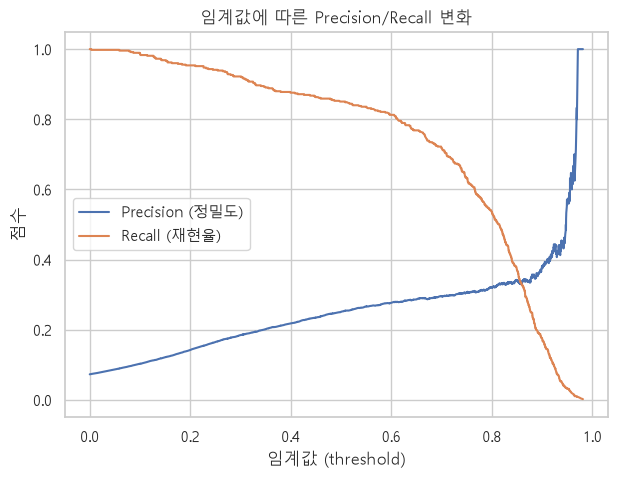

In [14]:
# ──────────────────────────────────────────────────────────
# 6) 임계값(threshold) 튜닝 — 확률을 직접 뽑아서 기준점 탐색
# ──────────────────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve

# 로지스틱 회귀(class_weight='balanced')로 각 학생의 "이탈 확률"을 직접 뽑음
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)
proba = model.predict_proba(X_test)[:, 1]   # [:, 1] = "이탈(1)"일 확률만 추출

# 임계값을 0.1~0.9까지 바꿔가며 recall/precision이 어떻게 변하는지 확인
print(f"{'임계값':>6} {'recall':>8} {'precision':>10} {'F1':>8} {'이탈로 예측된 인원':>14}")
for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    pred_t = (proba >= t).astype(int)       # 확률이 t 이상이면 "이탈 위험군"으로 분류
    r = recall_score(y_test, pred_t)
    p = precision_score(y_test, pred_t, zero_division=0)
    f1 = f1_score(y_test, pred_t, zero_division=0)
    n_flagged = pred_t.sum()
    print(f"{t:>6.1f} {r:>8.3f} {p:>10.3f} {f1:>8.3f} {n_flagged:>14d}")

# 전 구간을 그래프로 한눈에 보기
precisions, recalls, thresholds = precision_recall_curve(y_test, proba)
plt.figure(figsize=(7, 5))
plt.plot(thresholds, precisions[:-1], label='Precision (정밀도)')
plt.plot(thresholds, recalls[:-1], label='Recall (재현율)')
plt.xlabel('임계값 (threshold)')
plt.ylabel('점수')
plt.title('임계값에 따른 Precision/Recall 변화')
plt.legend()
plt.grid(True)
plt.show()

# [해석 포인트]
# 임계값을 낮출수록(0.1에 가까울수록): recall↑(더 많이 잡아냄), precision↓(오탐 늘어남), "이탈 예측 인원"도 늘어남
# 임계값을 높일수록(0.9에 가까울수록): recall↓, precision↑, 예측 인원도 줄어듦
#
# "이탈로 예측된 인원" 컬럼이 실무적으로 중요함 — 이 인원만큼 실제로 상담/연락 등 개입이 들어가야 하니까,
# 담당 인력이 감당할 수 있는 규모인지도 임계값 선택 기준이 됨

## 7. 모델 검증

In [39]:
# ──────────────────────────────────────────────────────────
# XGBoost 비교 검증 — 두 모델(로지스틱, RandomForest)로 충분한지 확인
# ──────────────────────────────────────────────────────────
from xgboost import XGBClassifier

# class_weight='balanced' 대신 XGBoost는 scale_pos_weight를 씀
# (음성 클래스 수 / 양성 클래스 수 비율만큼 소수 클래스에 가중치를 줌)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}")  # 대략 12~13 정도 나올 것

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,                       # RandomForest보다 얕게 (과적합 방지, 보통 XGBoost는 더 얕아도 됨)
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
# X_train2/X_test2: VLE 중복 피처 제거한 최종 버전 사용
xgb.fit(X_train2, y_train)
pred_xgb = xgb.predict(X_test2)

print("XGBoost (scale_pos_weight 적용)")
print(f"  정확도(accuracy) : {accuracy_score(y_test, pred_xgb):.3f}")
print(f"  재현율(recall)   : {recall_score(y_test, pred_xgb):.3f}")
print(f"  정밀도(precision): {precision_score(y_test, pred_xgb):.3f}")
print(f"  F1               : {f1_score(y_test, pred_xgb):.3f}")
print()

importance_xgb = pd.Series(xgb.feature_importances_, index=X_train2.columns)
print("피처 중요도 상위 10개 (XGBoost):")
print(importance_xgb.sort_values(ascending=False).head(10))

# [비교 기준]
# 로지스틱(balanced): F1 0.388
# RandomForest(정리 후): F1 0.386
# → XGBoost가 이 두 값보다 뚜렷하게(대략 0.05 이상) 높게 나오면 "모델 종류가 중요했다"는 뜻이고,
#   비슷한 범위(0.38~0.40)면 지금까지의 결론(피처가 모델 선택보다 중요)이 맞다는 뜻

scale_pos_weight = 12.71


XGBoost (scale_pos_weight 적용)
  정확도(accuracy) : 0.827
  재현율(recall)   : 0.825
  정밀도(precision): 0.273
  F1               : 0.411

피처 중요도 상위 10개 (XGBoost):
code_module_GGG               0.239595
avg_score_28                  0.143390
code_module_EEE               0.111277
region_Scotland               0.053234
active_days_28                0.026861
module_presentation_length    0.026485
studied_credits               0.023317
code_module_CCC               0.016931
distinct_resources_28         0.016179
region_Ireland                0.014877
dtype: float32


# 3. 최종 정리 및 결론

## 프로젝트 목표
개강 후 **28일 이내에 이탈할 위험이 있는 학생을 조기에 예측**해서, 담당 인력이 개입(상담·연락 등)할 수 있도록 지원.

## 데이터 파이프라인
1. Docker Postgres에 OULAD 7개 테이블 적재, PK/FK 관계 정리
2. SQL 뷰(`v_student_early_signal`)로 학생×과목 단위 "28일 컷오프" 피처 테이블 생성 → `통합쿼리.csv`(32,593행)
3. 정답 유출 컬럼(`final_result`, `label_churn`, `date_unregistration`) 제외, 결측치 처리, 범주형 인코딩
   - `age_band`의 `'55<='` 값은 XGBoost가 피처 이름에 `<` 문자를 허용하지 않아 `'55+'`로 치환 (인코딩 전 처리)
4. train/test 분리(80/20, stratify), 수치형 피처 표준화

## 모델 비교

| 모델 | class_weight / 기타 | Accuracy | Recall | Precision | F1 |
|---|---|---|---|---|---|
| 로지스틱 회귀 | None | 0.929 | 0.082 | 0.591 | 0.144 |
| 로지스틱 회귀 | balanced | 0.804 | 0.851 | 0.251 | 0.388 |
| RandomForest | balanced | 0.813 | 0.823 | 0.257 | 0.391 |
| RandomForest (중복 피처 제거) | balanced | 0.810 | 0.821 | 0.252 | 0.386 |
| XGBoost (중복 피처 제거) | scale_pos_weight=12.71 | 0.827 | 0.825 | 0.273 | **0.411** |

→ 4개 모델 모두 recall 0.82~0.85대로 비슷하게 이탈 위험군을 잘 잡아냄. XGBoost가 F1 기준으로는 가장 높지만(0.411),
  다른 모델들(0.386~0.391)과 큰 차이는 아님 → 여전히 "모델 선택보다 피처 설계가 더 중요하다"는 결론 유지.
→ `class_weight=None`(기본값)은 정확도만 높아 보이고 실제 이탈생을 거의 못 잡아내므로 반드시 `balanced`(또는 `scale_pos_weight`) 사용.

## 핵심 발견: 어떤 신호가 이탈을 가장 잘 예고하는가

1. **평가 제출 관련 신호가 압도적으로 중요함** (로지스틱/RandomForest 기준 피처 중요도 합계 약 44%)
   - 28일 안에 뭐라도 하나 제출한 학생의 이탈률은 1.9%, 미제출 학생은 16.4% — 8배 이상 차이
   - 제출자 안에서도 점수가 낮을수록 이탈률이 높아지는 패턴 존재 (상관계수 -0.091, 약하지만 유의미)
2. **VLE(온라인 자료) 참여도는 두 번째로 중요한 신호** (합계 약 19%)
   - 클릭수/접속일수/자료 다양성 3개 지표가 서로 0.69~0.76으로 겹쳐서, 중복 없이 접속일수(active_days_28) 하나로 정리해도 성능 손실 없음
3. `code_module`(특히 CCC, GGG), `studied_credits`(신청 학점)도 유의미한 보조 신호

**모델별 피처 중요도 차이 (주의할 점)**: RandomForest/로지스틱은 `avg_score_28`, `n_assessment_submitted_28` 등 "제출 관련" 피처를 최상위로 꼽은 반면,
XGBoost는 `code_module_GGG`(0.240)와 `code_module_EEE`(0.111)를 가장 중요한 피처로 꼽았고 `avg_score_28`(0.143)은 2위로 밀림.
→ 트리 구조(얕은 depth=4)와 boosting 방식 차이로 특정 과목 구분이 먼저 분기점으로 잡히는 경향 때문으로 추정.
→ **하나의 모델 결과만으로 "가장 중요한 피처"를 단정하지 말고, 여러 모델의 피처 중요도를 함께 참고해서 해석하는 것을 권장.**

**실무 시사점**: 단순 로그인 알림보다 "첫 과제 제출 여부"를 기준으로 조기 개입하는 전략이 더 효과적일 가능성이 높음.

## 임계값(threshold) 권장안

| 임계값 | Recall | Precision | 이탈 예측 인원(test 6,519명 기준) |
|---|---|---|---|
| 0.4 | 0.876 | 0.218 | 1,910명 (29.3%) |
| 0.5 | 0.851 | 0.251 | 1,609명 (24.7%) |
| 0.7 (F1 최고점) | 0.718 | 0.295 | 1,154명 (17.7%) |
| 0.8 | 0.535 | 0.321 | 792명 (12.1%) |

- 놓치는 비용(false negative)이 오탐 비용(false positive)보다 크다고 보면 **0.4~0.5 구간** 추천 (recall 85% 이상 확보)
- 개입 인력이 제한적이면 **0.7~0.8 구간**으로 좁혀서 우선순위 높은 학생부터 접근
- 최종 숫자는 팀의 실제 개입 여력에 맞춰 논의 후 확정 필요
- (위 표는 로지스틱 회귀 기준. XGBoost 등 다른 모델로 임계값을 다시 잡으면 수치가 달라질 수 있음)

## 한계 및 다음 단계
- `studentAssessment`는 `code_module`/`code_presentation` 정보가 없어 `studentInfo`와 직접 FK 연결 불가 (구조적 한계)
- `avg_submit_delay_28`의 결측치를 0으로 채워서 "제출 안 함"과 "마감일에 딱 제출"이 값만으로는 구분 안 됨 (다른 피처로 보완 가능)
- `code_presentation`(학기)을 통째로 제외했는데, 추후 "2월/10월 개강" 같은 계절성 피처로 재도입 고려 가능
- 모델별로 피처 중요도 1위가 다르게 나오는 현상(위 "핵심 발견" 참고)은 추가 검증(SHAP 값 비교 등) 필요
- 팀 논의로 최종 임계값 확정 → 결과를 팀 보고서/발표 자료로 정리